In [154]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import jax.numpy as np

import dLux as dl
import dLux.utils as dlu
import dLuxToliman as dlT

In [155]:
ratio = 1  # Ratio to scale the aperture by (e.g. 5 => 5-inch aperture becomes 1-inch aperture)
aperture_npix = 500  # Number of pixels across the aperture
aperture_diameter = 0.125 / ratio  # Clear aperture diameter (m)
# secondary_diameter = 0.032 / ratio  # Secondary mirror diameter (m)

# Construct a simple circular aperture
coords = dlu.pixel_coords(aperture_npix, aperture_diameter)
aperture = dlu.circle(coords, 0.5 * aperture_diameter)

# Define our detector properties
psf_npix = 1000  # Number of pixels in the PSF
psf_pixel_scale = 50e-3  # 50 mili-arcseconds
oversample = 1  # Oversampling factor for the PSF


In [156]:
amplitude = np.pi/4
period = 12.5e-3*np.sqrt(2)

X, Y = dlu.pixel_coords(aperture_npix, aperture_diameter)

# Rotate the coordinates
R, PHI = dlu.cart2polar([X, Y])
PHI += np.pi / 4  # Rotate by 45 degrees
X, Y = dlu.polar2cart([R, PHI])

# Define the sine argument value to get the correct period
B = 2 * np.pi / period

# Creating gratings
grating = (amplitude * np.cos(B * Y) + amplitude * np.cos(B * X)) / 4
# anti_grating = (
#     amplitude * np.cos(B * Y + np.pi)
#     + amplitude * np.cos(B * X + np.pi)
# ) / 4

full_grating = grating

tile_top = np.concatenate((np.ones((50,50)), -np.ones((50,50))), axis=1)
tile_bottom = np.concatenate((-np.ones((50,50)), np.ones((50,50))), axis=1)
tile = np.concatenate((tile_top, tile_bottom), axis=0)
tile_grating = tile * np.sqrt(np.mean(full_grating**2))
tile_grating = np.tile(
            tile_grating,
            (full_grating.shape[0] // tile_grating.shape[0]+1, full_grating.shape[1] // tile_grating.shape[1] + 1),
        )[:full_grating.shape[0],:full_grating.shape[1]]


In [157]:
# Define the optical layers
# Note here we can pass in a tuple of (key, layer) paris to be able to 
# access the layer from the optics object with the key!
layers = [
    (
        "aperture",
        dl.layers.TransmissiveLayer(transmission=aperture, normalise=True),
    ),
    (
        "aberrations",
        dl.layers.AberratedLayer(phase=full_grating),
    )
]

# Construct the optics object
optics = dl.AngularOpticalSystem(
    aperture_npix, aperture_diameter, layers, psf_npix, psf_pixel_scale, oversample
)

# Models some wavelengths through the system
wavels = 1e-9 * np.linspace(530,640, 10)
psf = optics.propagate(wavels)
sine_psf = psf

# Get out aperture transmission for plotting
# Note we can use the 'aperture' key we supplied in the layers to access 
# that layer directly from the optics object!
transmission = optics.aperture.transmission

# Let examine the optics object! The dLux framework has in-built 
# pretty-printing, so we can just print the object to see what it contains.
print(optics)


AngularOpticalSystem(
  wf_npixels=500,
  diameter=0.125,
  layers={
    'aperture': TransmissiveLayer(transmission=f32[500,500], normalise=True),
    'aberrations': AberratedLayer(opd=None, phase=f32[500,500])
  },
  psf_npixels=1000,
  oversample=1,
  psf_pixel_scale=0.05
)


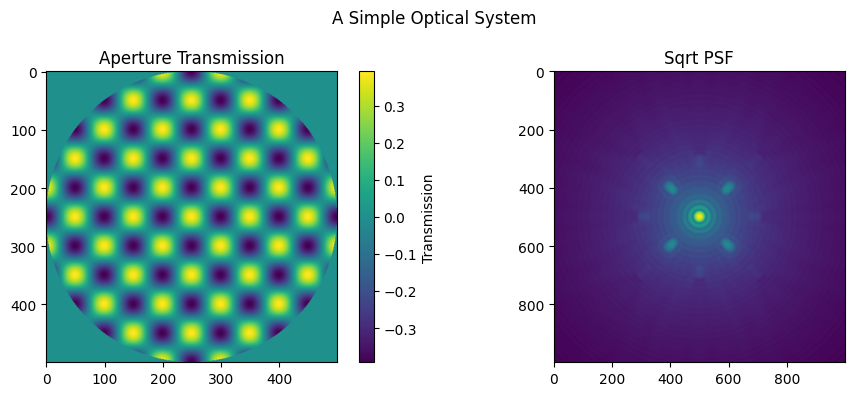

In [158]:
# Plot the results
plt.figure(figsize=(10, 4))
plt.suptitle("A Simple Optical System")
plt.subplot(1, 2, 1)
plt.title("Aperture Transmission")
plt.imshow(transmission*full_grating)
plt.colorbar(label="Transmission")

plt.subplot(1, 2, 2)
plt.title("Sqrt PSF")
plt.imshow(psf**0.1)
# plt.colorbar(label="Sqrt Intensity")
plt.tight_layout()
plt.show()

In [159]:
# Define the optical layers
# Note here we can pass in a tuple of (key, layer) paris to be able to 
# access the layer from the optics object with the key!
layers = [
    (
        "aperture",
        dl.layers.TransmissiveLayer(transmission=aperture, normalise=True),
    ),
    (
        "aberrations",
        dl.layers.AberratedLayer(phase=tile_grating),
    )
]

# Construct the optics object
optics = dl.AngularOpticalSystem(
    aperture_npix, aperture_diameter, layers, psf_npix, psf_pixel_scale, oversample
)

# Models some wavelengths through the system
wavels = 1e-9 * np.linspace(530,640, 10)
psf = optics.propagate(wavels)
binary_psf = psf

# Get out aperture transmission for plotting
# Note we can use the 'aperture' key we supplied in the layers to access 
# that layer directly from the optics object!
transmission = optics.aperture.transmission

# Let examine the optics object! The dLux framework has in-built 
# pretty-printing, so we can just print the object to see what it contains.
print(optics)

AngularOpticalSystem(
  wf_npixels=500,
  diameter=0.125,
  layers={
    'aperture': TransmissiveLayer(transmission=f32[500,500], normalise=True),
    'aberrations': AberratedLayer(opd=None, phase=f32[500,500])
  },
  psf_npixels=1000,
  oversample=1,
  psf_pixel_scale=0.05
)


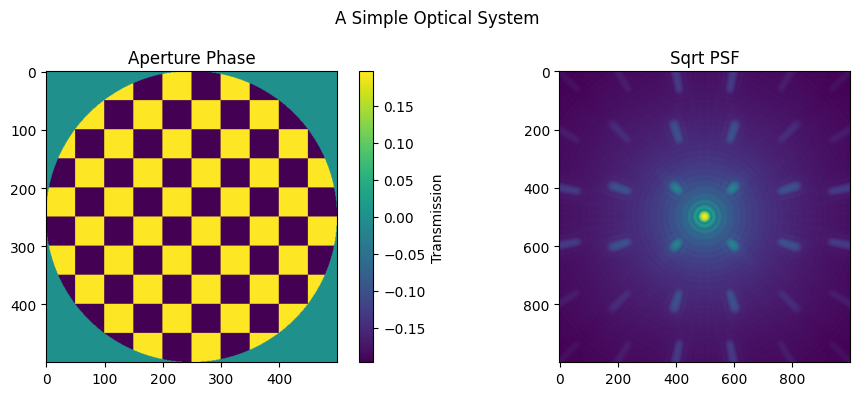

In [160]:
# Plot the results
plt.figure(figsize=(10, 4))
plt.suptitle("A Simple Optical System")
plt.subplot(1, 2, 1)
plt.title("Aperture Phase")
plt.imshow(transmission*tile_grating)
plt.colorbar(label="Transmission")

plt.subplot(1, 2, 2)
plt.title("Sqrt PSF")
plt.imshow(psf**0.1)
# plt.colorbar(label="Sqrt Intensity")
plt.tight_layout()
plt.show()

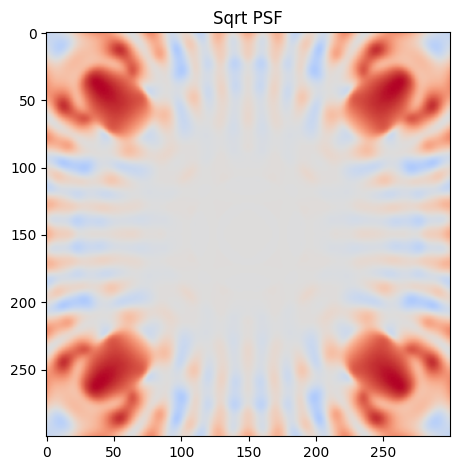

In [173]:
diff = (sine_psf[350:650,350:650]**0.1) - (binary_psf[350:650,350:650]**0.1)
mabs = np.nanmax(np.abs(diff))

plt.title("Sqrt PSF")
plt.imshow(diff, vmin=-mabs, vmax=mabs,cmap='coolwarm')
# plt.colorbar(label="Sqrt Intensity")
plt.tight_layout()
plt.show()

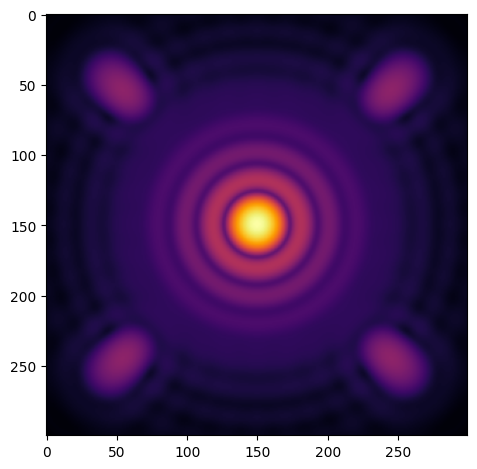

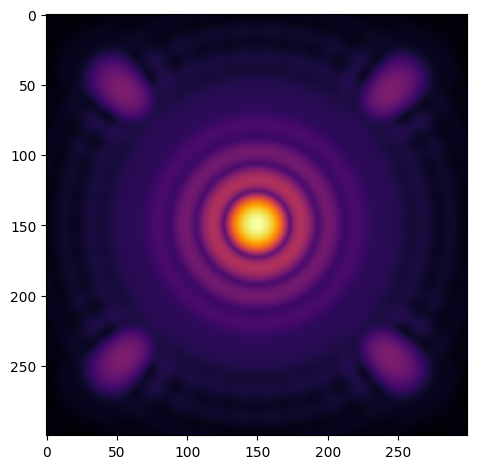

0.9885047


In [172]:
plt.imshow(sine_psf[350:650,350:650]**0.1, cmap='inferno')
# plt.colorbar(label="Sqrt Intensity")
plt.tight_layout()
plt.show()
plt.imshow(binary_psf[350:650,350:650]**0.1, cmap='inferno')
# plt.colorbar(label="Sqrt Intensity")
plt.tight_layout()
plt.show()
flux_sine = sum(sum(sine_psf[350:650,350:650]))
flux_binary = sum(sum(binary_psf[350:650,350:650]))     

print(flux_binary / flux_sine)